# Regressão de Contagens

## 1. Preparação do Ambiente e Importação de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 2. Carregamento da base de dados

In [2]:
df = pd.read_excel('simulacao_cancer_pele.xlsx')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Regiao        1000 non-null   object
 1   Faixa_Etaria  1000 non-null   object
 2   Populacao     1000 non-null   int64 
 3   Casos         1000 non-null   int64 
 4   Age_Idx       1000 non-null   int64 
 5   is_Dallas     1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB
None


,Regiao,Faixa_Etaria,Populacao,Casos,Age_Idx,is_Dallas
0,Minneapolis,65-74,67134,7,5,0
1,Dallas,75-84,30491,8,6,1
2,Minneapolis,15-24,11341,0,0,0
3,Minneapolis,15-24,54623,0,0,0
4,Minneapolis,15-24,10338,0,0,0


## 2. Análise Descritiva e Multicolinearidade

Realizamos o Pairplot para observar a distribuição das contagens e a relação com a população. Em seguida, verificamos a multicolinearidade via Heatmap e VIF (Variance Inflation Factor)

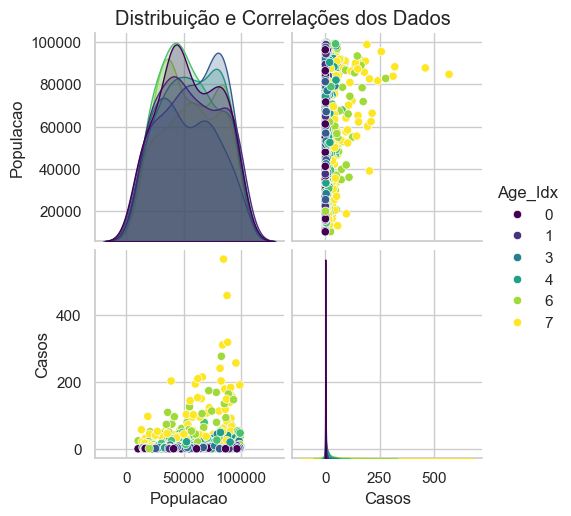

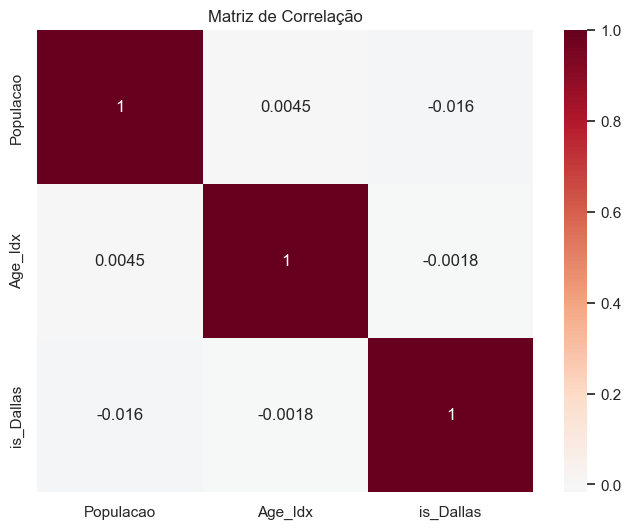


--- Tabela de VIF ---
    Variável       VIF
0      const  4.271511
1    Age_Idx  1.000003
2  is_Dallas  1.000003


In [3]:
# 2.1 Análise Visual
sns.pairplot(df[['Populacao', 'Casos', 'Age_Idx']], diag_kind='kde', hue='Age_Idx', palette='viridis')
plt.suptitle("Distribuição e Correlações dos Dados", y=1.02)
plt.show()

# 2.2 Verificação de Multicolinearidade
plt.figure(figsize=(8, 6))
correlation_matrix = df[['Populacao', 'Age_Idx', 'is_Dallas']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title("Matriz de Correlação")
plt.show()

# Cálculo do VIF
X_vif = df[['Age_Idx', 'is_Dallas']]
X_vif = sm.add_constant(X_vif)
vif_df = pd.DataFrame()
vif_df["Variável"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("\n--- Tabela de VIF ---")
print(vif_df)

3. Divisão da Base e Ajuste do Modelo

Dividimos os dados para garantir que a validação ocorra em dados não vistos pelo modelo. O termo de Offset (log da população) é incluído para modelar a taxa de incidência.

In [4]:
# Divisão Treino/Teste (80/20)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [5]:
# Ajuste do Modelo de Poisson
formula = "Casos ~ Regiao * Faixa_Etaria"
mod_poisson = smf.glm(formula, data=df_train, offset=np.log(df_train['Populacao']), 
                      family=sm.families.Poisson()).fit()

print(mod_poisson.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Casos   No. Observations:                  800
Model:                            GLM   Df Residuals:                      784
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4529.0
Date:                Tue, 17 Mar 2026   Deviance:                       6706.7
Time:                        16:56:21   Pearson chi2:                 7.11e+03
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [6]:
# --- AVALIAÇÃO DE SUPERDISPERSÃO (Média vs Variância) ---
# Calculando a média e variância observada por grupos para ilustrar
stats_check = df_train.groupby(['Regiao', 'Faixa_Etaria'])['Casos'].agg(['mean', 'var']).reset_index()
print("\n--- Verificação Teórica: Média vs Variância por Grupo ---")
print(stats_check.head())


# Teste Formal de Dispersão
disp_ratio = mod_poisson.pearson_chi2 / mod_poisson.df_resid
p_val_disp = stats.chi2.sf(mod_poisson.pearson_chi2, mod_poisson.df_resid)

print(f"\nRazão de Dispersão: {disp_ratio:.4f}")
print(f"P-valor (H0: Média = Variância): {p_val_disp:.4g}")

if disp_ratio > 1.2:
    print("ALERTA: Superdispersão detectada (Ratio > 1). O modelo de Poisson subestima os erros padrão.")


--- Verificação Teórica: Média vs Variância por Grupo ---
   Regiao Faixa_Etaria       mean         var
0  Dallas        15-24   0.611111    0.657233
1  Dallas        25-34   1.425532    3.814986
2  Dallas        35-44   3.584906   15.285922
3  Dallas        45-54   5.510204   27.296769
4  Dallas        55-64  14.745763  170.675628

Razão de Dispersão: 9.0654
P-valor (H0: Média = Variância): 0
ALERTA: Superdispersão detectada (Ratio > 1). O modelo de Poisson subestima os erros padrão.


In [7]:
df_train['Casos'].agg(['mean', 'var'])

mean      16.555000
var     1868.470063
Name: Casos, dtype: float64

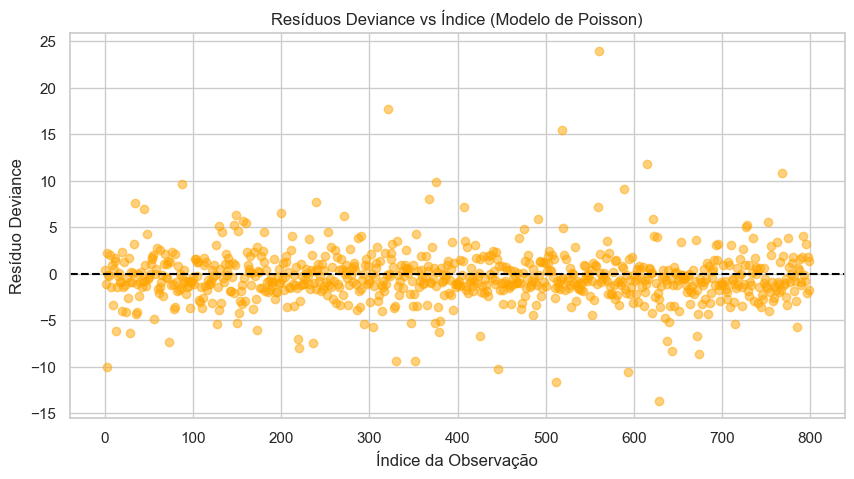

In [8]:
# Resíduos Deviance x Índice
residuos_dev_p = mod_poisson.resid_deviance

plt.figure(figsize=(10, 5))
plt.scatter(range(len(residuos_dev_p)), residuos_dev_p, color='orange', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Resíduos Deviance vs Índice (Modelo de Poisson)")
plt.xlabel("Índice da Observação")
plt.ylabel("Resíduo Deviance")
plt.show()

## 3. Modelo II: Binomial Negativa 

Utilizamos este modelo para tratar a superdispersão, introduzindo o parâmetro de forma $\alpha$.

In [9]:
# Ajuste do Modelo Binomial Negativa
# Nota: Utilizamos o valor de alpha estimado ou fixo para comparação
mod_nb = smf.glm(formula, data=df_train, offset=np.log(df_train['Populacao']), 
                 family=sm.families.NegativeBinomial(alpha=0.5)).fit()

print(mod_nb.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Casos   No. Observations:                  800
Model:                            GLM   Df Residuals:                      784
Model Family:        NegativeBinomial   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2120.2
Date:                Tue, 17 Mar 2026   Deviance:                       836.08
Time:                        16:56:21   Pearson chi2:                     750.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.9682
Covariance Type:            nonrobust                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

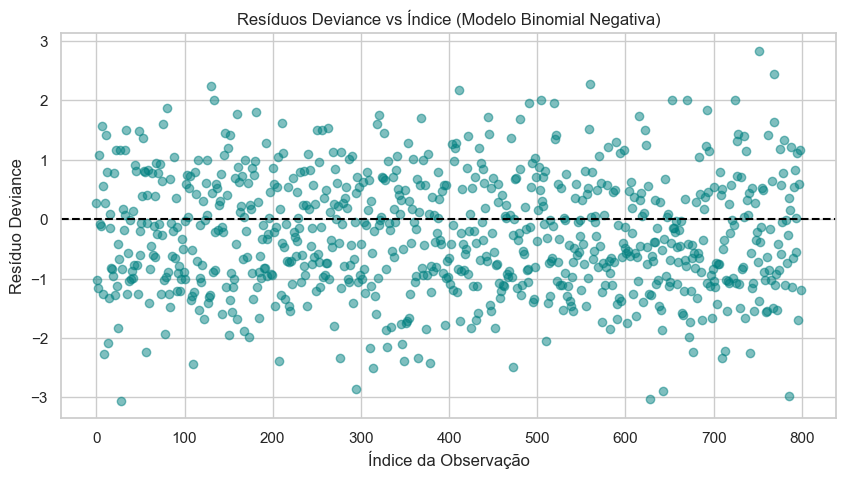

In [10]:
# Resíduos Deviance x Índice
residuos_dev_nb = mod_nb.resid_deviance

plt.figure(figsize=(10, 5))
plt.scatter(range(len(residuos_dev_nb)), residuos_dev_nb, color='teal', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Resíduos Deviance vs Índice (Modelo Binomial Negativa)")
plt.xlabel("Índice da Observação")
plt.ylabel("Resíduo Deviance")
plt.show()

## 4. Validação Estatística do Modelo

### 4.1 Teste de Razão de Verossimilhança (LRT)

- H0: O modelo nulo é suficiente.
- H1: O modelo com preditores/interação fornece um ajuste superior.

In [11]:
# 4.2 Teste de Razão de Verossimilhança (LRT) - Comparando Modelos
# Comparamos o Poisson (Nulo em relação à dispersão) vs Binomial Negativa
# Ou comparamos o NB contra um modelo NB sem preditores (Modelo Nulo)
mod_nb_null = smf.glm('Casos ~ 1', data=df_train, offset=np.log(df_train['Populacao']), 
                      family=sm.families.NegativeBinomial(alpha=0.5)).fit()

lr_stat = 2 * (mod_nb.llf - mod_nb_null.llf)
p_val_lr = stats.chi2.sf(lr_stat, mod_nb.df_model)

print(f"\n--- Likelihood Ratio Test (LRT) ---")
print(f"Estatística: {lr_stat:.4f} | P-valor: {p_val_lr:.4g}")


--- Likelihood Ratio Test (LRT) ---
Estatística: 2759.1004 | P-valor: 0


## 5. Métricas de Erro e Performance
Avaliamos a proximidade da resposta real através do MAE e RMSE no conjunto de teste.

In [12]:
# 4.1 Teste de Pearson (Observed vs Predicted) no Teste
y_obs = df_test['Casos']
y_pred_nb = mod_nb.predict(df_test, offset=np.log(df_test['Populacao']))
corr, p_pearson = stats.pearsonr(y_obs, y_pred_nb)

print(f"--- Validação de Pearson (Modelo BN) ---")
print(f"H0: Sem relação entre Obs e Pred | H1: Relação Significativa")
print(f"Correlação: {corr:.4f} | P-valor: {p_pearson:.4g}")



--- Validação de Pearson (Modelo BN) ---
H0: Sem relação entre Obs e Pred | H1: Relação Significativa
Correlação: 0.9060 | P-valor: 7.491e-76

--- Likelihood Ratio Test (LRT) ---
Estatística: 2759.1004 | P-valor: 0


1. O Coeficiente de Correlação ($r = 0,9060$)O valor de 0,9060 representa a força da associação linear entre os valores reais (observados) e os valores que o seu modelo previu.

Interpretação: Em uma escala de 0 a 1, um valor acima de 0,90 é considerado uma correlação fortíssima.O que isso diz sobre o modelo: 

Significa que o modelo "rastreia" muito bem a realidade. Quando o número real de casos de câncer aumenta em um determinado distrito, o modelo também prevê um aumento proporcional de forma muito precisa.2. O P-valor ($7,491 \times 10^{-76}$)Este número é a probabilidade de você encontrar uma correlação tão alta quanto essa se, na verdade, o modelo fosse completamente aleatório (ou seja, se a hipótese nula $H_0$ fosse verdadeira).Notação Científica: $7,491e-76$ é o mesmo que $0,0000...$ (com 75 zeros antes do 7). É um valor virtualmente zero.Decisão Estatística: Como o p-valor é muito menor que o nível de significância padrão ($p < 0,05$), nós rejeitamos a hipótese nula ($H_0$) com extrema confiança.

In [ ]:
# 4.2 Teste de Razão de Verossimilhança (LRT) - Comparando Modelos
# comparamos o NB contra um modelo NB sem preditores (Modelo Nulo)
mod_nb_null = smf.glm('Casos ~ 1', data=df_train, offset=np.log(df_train['Populacao']), 
                      family=sm.families.NegativeBinomial(alpha=0.5)).fit()

lr_stat = 2 * (mod_nb.llf - mod_nb_null.llf)
p_val_lr = stats.chi2.sf(lr_stat, mod_nb.df_model)

print(f"\n--- Likelihood Ratio Test (LRT) ---")
print(f"Estatística: {lr_stat:.4f} | P-valor: {p_val_lr:.4g}")

Métricas de Validação:
- Erro Médio Absoluto (MAE): 7.72
- Raiz do Erro Quadrático Médio (RMSE): 16.14


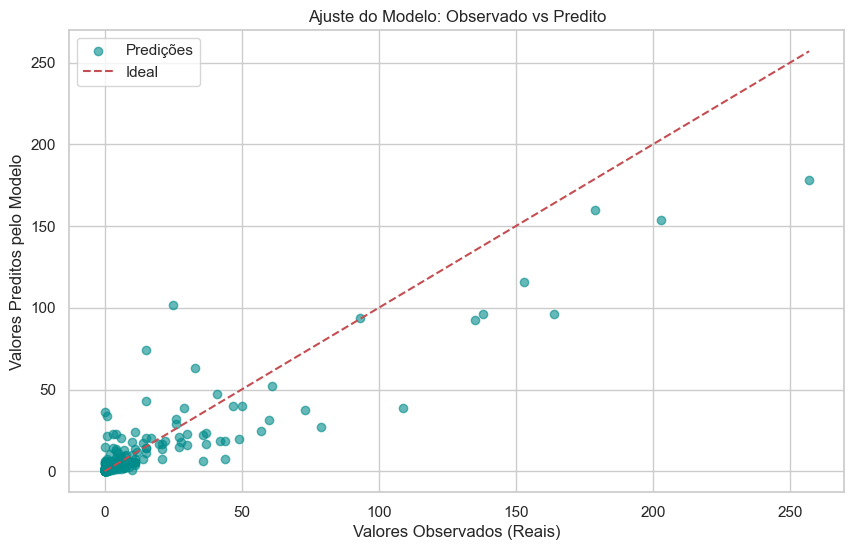

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_obs, y_pred_nb)
rmse = np.sqrt(mean_squared_error(y_obs, y_pred_nb))

print(f"Métricas de Validação:")
print(f"- Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"- Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}")

# Gráfico de Validação
plt.figure(figsize=(10, 6))
plt.scatter(y_obs, y_pred_nb, alpha=0.6, color='darkcyan', label='Predições')
plt.plot([y_obs.min(), y_obs.max()], [y_obs.min(), y_obs.max()], 'r--', label='Ideal')
plt.xlabel("Valores Observados (Reais)")
plt.ylabel("Valores Preditos pelo Modelo")
plt.title("Ajuste do Modelo: Observado vs Predito")
plt.legend()
plt.show()